# Step 5: Customer Lifetime Value (CLV) Analysis

## Goal
Estimate the total value each customer brings to the business over their lifetime.

## Why this matters
Understanding CLV helps businesses identify high-value customers, prioritize retention efforts, and allocate marketing resources efficiently.

## Approach
- SQL to aggregate customer revenue and tenure
- Python to calculate CLV
- Combine CLV with RFM segmentation for business insights

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = sqlite3.connect('../db/batchbridge.db')

clv_df = pd.read_sql_query("""
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS total_transactions,
    SUM(SalesAmount) AS total_revenue,
    AVG(SalesAmount) AS avg_order_value,
    MIN(date(InvoiceDate)) AS first_purchase,
    MAX(date(InvoiceDate)) AS last_purchase,
    CAST(julianday(MAX(date(InvoiceDate))) - julianday(MIN(date(InvoiceDate))) AS INTEGER) AS lifespan_days
FROM ecommerce_cleaned
GROUP BY CustomerID;
""", conn)

clv_df.head()

,CustomerID,total_transactions,total_revenue,avg_order_value,first_purchase,last_purchase,lifespan_days
0,12346.0,1,77183.60,77183.600000,2011-01-18,2011-01-18,0
1,12347.0,7,4310.00,23.681319,2010-12-07,2011-12-07,365
2,12348.0,4,1797.24,57.975484,2010-12-16,2011-09-25,283
3,12349.0,1,1757.55,24.076027,2011-11-21,2011-11-21,0
4,12350.0,1,334.40,19.670588,2011-02-02,2011-02-02,0


## CLV Calculation

Customer Lifetime Value (CLV) is calculated using:

CLV = Average Order Value × Purchase Frequency × Customer Lifespan

This provides an estimate of how much revenue each customer generates over time.

In [2]:
clv_df['purchase_frequency'] = clv_df['total_transactions'] / clv_df['lifespan_days'].replace({0: 1})  # Avoid division by zero

clv_df["CLV"] = (
    clv_df["avg_order_value"] *
    clv_df["purchase_frequency"] *
    clv_df["lifespan_days"]
)

clv_df.head()

,CustomerID,total_transactions,total_revenue,avg_order_value,first_purchase,last_purchase,lifespan_days,purchase_frequency,CLV
0,12346.0,1,77183.60,77183.600000,2011-01-18,2011-01-18,0,1.000000,0.000000
1,12347.0,7,4310.00,23.681319,2010-12-07,2011-12-07,365,0.019178,165.769231
2,12348.0,4,1797.24,57.975484,2010-12-16,2011-09-25,283,0.014134,231.901935
3,12349.0,1,1757.55,24.076027,2011-11-21,2011-11-21,0,1.000000,0.000000
4,12350.0,1,334.40,19.670588,2011-02-02,2011-02-02,0,1.000000,0.000000


In [3]:
rfm = pd.read_csv("../data/rfm_final.csv")

In [4]:
clv_merged = clv_df.merge(rfm[['CustomerID', 'Segment']], on='CustomerID')

clv_merged.head()

,CustomerID,total_transactions,total_revenue,avg_order_value,first_purchase,last_purchase,lifespan_days,purchase_frequency,CLV,Segment
0,12346.0,1,77183.60,77183.600000,2011-01-18,2011-01-18,0,1.000000,0.000000,Regular
1,12347.0,7,4310.00,23.681319,2010-12-07,2011-12-07,365,0.019178,165.769231,At Risk
2,12348.0,4,1797.24,57.975484,2010-12-16,2011-09-25,283,0.014134,231.901935,At Risk
3,12349.0,1,1757.55,24.076027,2011-11-21,2011-11-21,0,1.000000,0.000000,Regular
4,12350.0,1,334.40,19.670588,2011-02-02,2011-02-02,0,1.000000,0.000000,Regular


In [5]:
clv_merged.groupby('Segment')['CLV'].mean().sort_values(ascending=False)

Segment
At Risk    433.353731
VIP        218.283606
Loyal       49.265859
Regular     39.218624
Name: CLV, dtype: float64

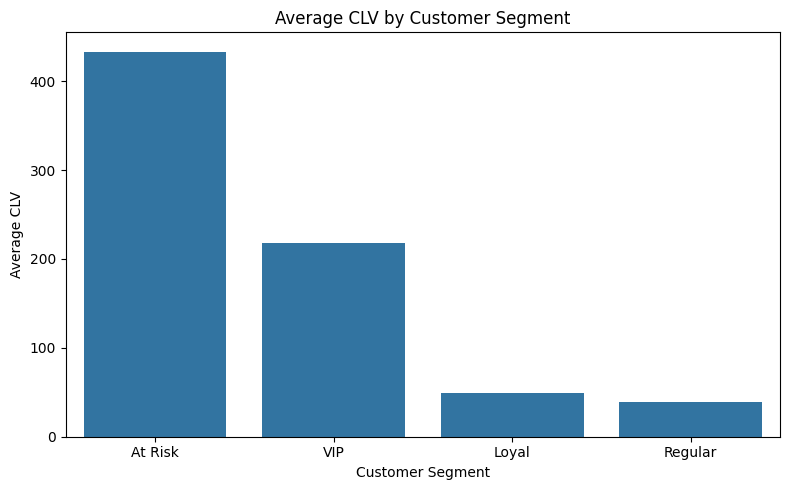

In [6]:
clv_segment = (
    clv_merged.groupby('Segment')['CLV']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=clv_segment,
    x='Segment',
    y='CLV'
)

plt.title("Average CLV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average CLV")

plt.tight_layout()
plt.show()

## CLV Insights

The At Risk segment has the highest average Customer Lifetime Value, indicating that customers who were previously highly engaged are no longer active.

This suggests a significant revenue risk, as the business is losing high-value customers.

VIP customers continue to generate strong value, but represent a smaller portion of the customer base due to stricter segmentation criteria.

These findings highlight an opportunity to implement targeted retention strategies aimed at re-engaging At Risk customers and preserving long-term revenue.